In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import chardet
import seaborn as sns
from textwrap import wrap

In [2]:
geneset=pd.read_csv('genesets/lim_cds_geneset.txt',header=0,sep='\t')

In [3]:
set_overlap={}
for c1 in geneset.columns:
    set_overlap[c1]={}
    for c2 in geneset.columns:
        set_overlap[c1][c2]=len(set(geneset[c1].dropna()).intersection(set(geneset[c2].dropna())))
max_overlap={}
for c1 in geneset.columns:
    max_overlap[c1]={}
    for c2 in geneset.columns:
        max_overlap[c1][c2]=len(set(geneset[c1].dropna()).union(set(geneset[c2].dropna())))

In [4]:
pairwiseov=pd.DataFrame(set_overlap)
norm=pd.DataFrame(max_overlap)

In [5]:
norm

,rev_CTL,HALLMARK_APOPTOSIS,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,Rev_Pyroptosis,REACTOME_REGULATED_NECROSIS,Rev_Ferroptosis
rev_CTL,56,214,197,106,109,120
HALLMARK_APOPTOSIS,214,161,302,198,203,220
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,197,302,143,193,200,207
Rev_Pyroptosis,106,198,193,51,80,113
REACTOME_REGULATED_NECROSIS,109,203,200,80,58,121
Rev_Ferroptosis,120,220,207,113,121,64


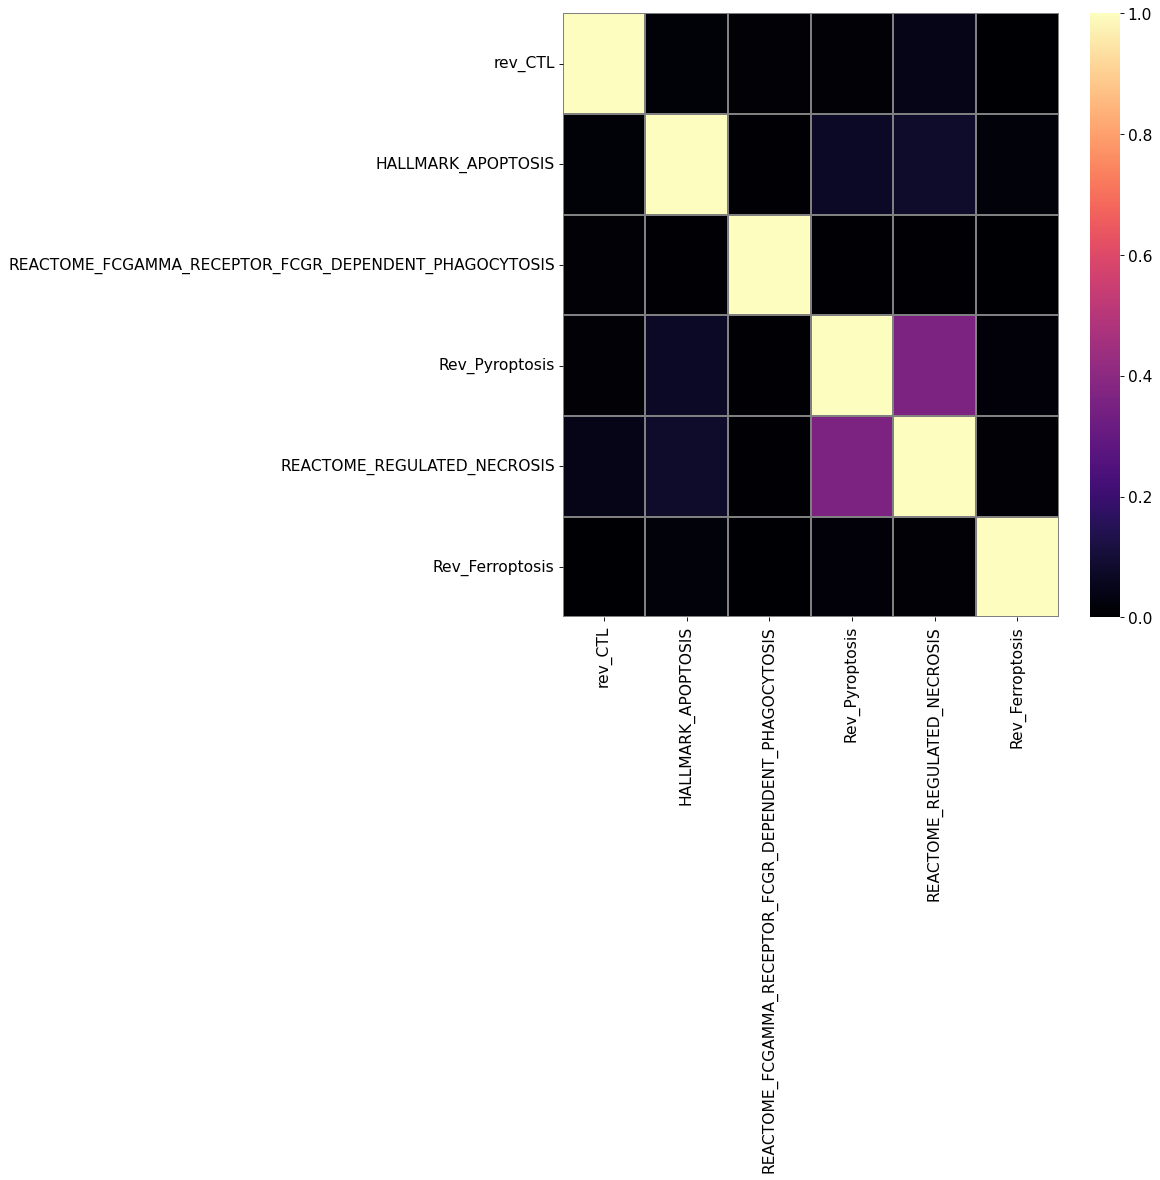

In [6]:
plt.rcParams["font.size"] = 14
nomroverlap=pairwiseov/norm
fig = plt.figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
res = sns.heatmap(nomroverlap.transpose(), cmap='magma',linewidths=0.1, linecolor='gray', xticklabels=True, yticklabels=True)
fig.savefig("heatmap_overlap.png")

<AxesSubplot:>

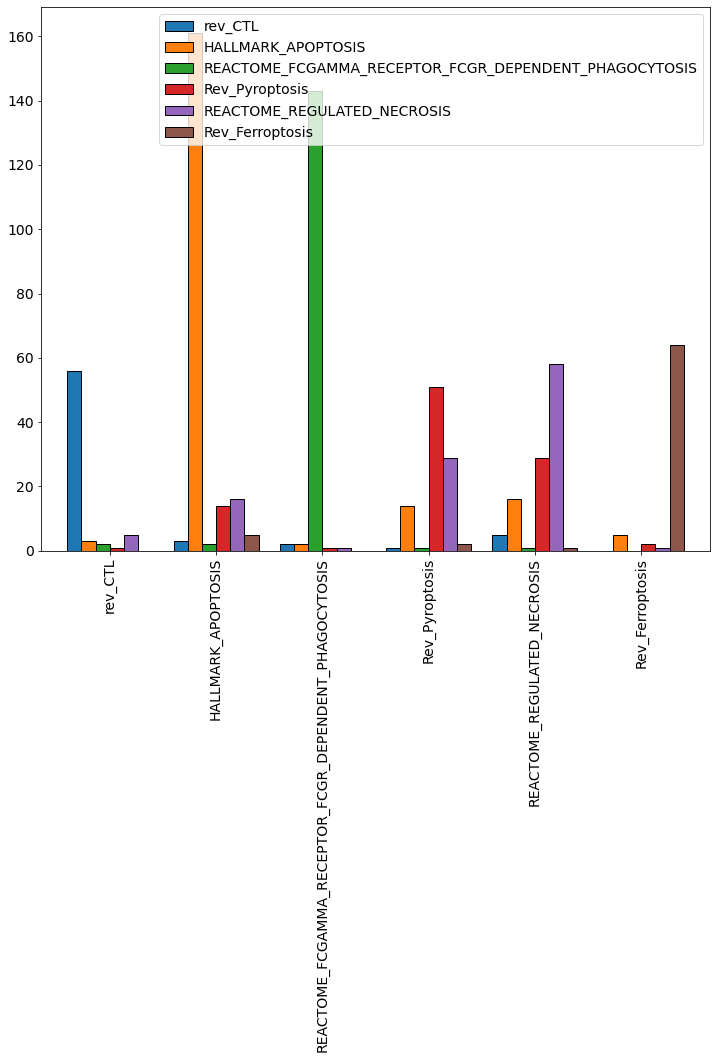

In [17]:
plt.rcParams["figure.figsize"] = (12,10)
pairwiseov.plot.bar(width=0.8,edgecolor='black')

In [7]:
rawdata = open("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TcgaTargetGTEX_phenotype_rev.csv", "rb").read()
chardet.detect(rawdata)

{'encoding': 'ISO-8859-1', 'confidence': 0.7285962189153715, 'language': ''}

In [8]:
cat_sample=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TcgaTargetGTEX_phenotype_rev.csv",index_col=0,encoding='ISO-8859-1')

In [9]:
cat_sample

,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
sample,,,,,,
TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
...,...,...,...,...,...,...
TARGET-20-PANPKN-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET
TARGET-20-PANLIR-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET
TARGET-20-PAPAWN-09,Acute Myeloid Leukemia,Acute Myeloid Leukemia,White blood cell,Primary Blood Derived Cancer - Bone Marrow,Male,TARGET


In [ ]:
genexpmatrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TcgaTargetGtex_rsem_gene_fpkm",sep="\t",index_col=0)

In [10]:
cat_sample.dropna(inplace=True,how='all')
cat_sdict=dict(cat_sample['primary disease or tissue']+"_"+cat_sample['_primary_site']+"_"+cat_sample['_sample_type'])

In [ ]:
genexpmatrix.index=genexpmatrix.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()

In [11]:
can_dict={}
can_dict_counts={}
for s in cat_sdict:
    if cat_sdict[s] not in can_dict.keys():
        can_dict[cat_sdict[s]]=[]
        can_dict[cat_sdict[s]].append(s)
    else:
        can_dict[cat_sdict[s]].append(s)
for c in can_dict:
    can_dict_counts[c]=len(can_dict[c])

In [12]:
can_dict["Breast Invasive Carcinoma_Breast_Primary Tumor"]

['TCGA-AO-A1KQ-01',
 'TCGA-E2-A14W-01',
 'TCGA-A1-A0SM-01',
 'TCGA-AR-A1AV-01',
 'TCGA-BH-A0B4-01',
 'TCGA-EW-A1PD-01',
 'TCGA-EW-A6SA-01',
 'TCGA-AC-A62V-01',
 'TCGA-BH-A0DD-01',
 'TCGA-AQ-A54O-01',
 'TCGA-D8-A1XS-01',
 'TCGA-A8-A085-01',
 'TCGA-A2-A25D-01',
 'TCGA-AC-A23H-01',
 'TCGA-AC-A3W6-01',
 'TCGA-B6-A0IC-01',
 'TCGA-BH-A1F8-01',
 'TCGA-C8-A26Y-01',
 'TCGA-D8-A1JK-01',
 'TCGA-E2-A9RU-01',
 'TCGA-LL-A6FP-01',
 'TCGA-A8-A08A-01',
 'TCGA-A8-A08L-01',
 'TCGA-E2-A15O-01',
 'TCGA-AN-A0FK-01',
 'TCGA-BH-A18N-01',
 'TCGA-BH-A1FG-01',
 'TCGA-D8-A73U-01',
 'TCGA-LL-A5YM-01',
 'TCGA-AC-A2FM-01',
 'TCGA-AC-A3HN-01',
 'TCGA-BH-A8FY-01',
 'TCGA-D8-A1XG-01',
 'TCGA-A2-A0CO-01',
 'TCGA-A2-A1G1-01',
 'TCGA-A8-A07Z-01',
 'TCGA-D8-A1XC-01',
 'TCGA-E9-A54X-01',
 'TCGA-A7-A56D-01',
 'TCGA-A8-A06Z-01',
 'TCGA-A8-A09I-01',
 'TCGA-A8-A0A1-01',
 'TCGA-AC-A2B8-01',
 'TCGA-AQ-A1H2-01',
 'TCGA-D8-A1XV-01',
 'TCGA-E2-A1LK-01',
 'TCGA-LL-A50Y-01',
 'TCGA-A8-A09Q-01',
 'TCGA-A8-A09Z-01',
 'TCGA-A8-A0AD-01',


In [12]:
tcgagenemap=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/probeMap_gencode.v23.annotation.gene.probemap",sep="\t",index_col=0)
enslist=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()
print(len(enslist))#ensids
print(len(list(set(enslist))))#unique ensids
tcgaensdict=dict(zip(tcgagenemap['gene'].values.tolist(),enslist))

60498
60498


In [14]:
tcgaensdict

{'DDX11L1': 'ENSG00000223972',
 'WASH7P': 'ENSG00000226210',
 'MIR6859-1': 'ENSG00000278267',
 'RP11-34P13.3': 'ENSG00000243485',
 'MIR1302-2': 'ENSG00000274890',
 'FAM138A': 'ENSG00000237613',
 'OR4G4P': 'ENSG00000268020',
 'OR4G11P': 'ENSG00000240361',
 'OR4F5': 'ENSG00000186092',
 'RP11-34P13.7': 'ENSG00000238009',
 'RP11-34P13.8': 'ENSG00000239945',
 'CICP27': 'ENSG00000233750',
 'RP11-34P13.15': 'ENSG00000268903',
 'RP11-34P13.16': 'ENSG00000269981',
 'RP11-34P13.14': 'ENSG00000239906',
 'RP11-34P13.13': 'ENSG00000241860',
 'RNU6-1100P': 'ENSG00000222623',
 'RP11-34P13.9': 'ENSG00000241599',
 'FO538757.3': 'ENSG00000279928',
 'FO538757.2': 'ENSG00000279457',
 'MIR6859-2': 'ENSG00000273874',
 'FO538757.1': 'ENSG00000275135',
 'AP006222.2': 'ENSG00000228463',
 'RPL23AP21': 'ENSG00000241670',
 'RPL23AP24': 'ENSG00000236679',
 'RP5-857K21.15': 'ENSG00000236743',
 'RP4-669L17.2': 'ENSG00000236601',
 'RP4-669L17.10': 'ENSG00000237094',
 'WBP1LP7': 'ENSG00000269732',
 'OR4F29': 'ENSG0000

In [13]:
genesetdict={}
for c in geneset.columns:
    genesetdict[c]=list(geneset[c].dropna().values)

In [14]:
genesetdict

{'rev_CTL': ['AGER',
  'AZGP1',
  'B2M',
  'CD1A',
  'CD1B',
  'CD1C',
  'CD1D',
  'CD1E',
  'CEACAM1',
  'CTSC',
  'CTSH',
  'CYRIB',
  'EMP2',
  'FADD',
  'FCGR2B',
  'GZMM',
  'HLA-A',
  'HLA-B',
  'HLA-DRA',
  'HLA-DRB1',
  'HLA-E',
  'HLA-F',
  'HLA-G',
  'HLA-H',
  'HPRT1',
  'IL12A',
  'IL12B',
  'IL12RB1',
  'IL23A',
  'IL23R',
  'IL7R',
  'KLRC1',
  'KLRD1',
  'LILRB1',
  'MICA',
  'MR1',
  'NECTIN2',
  'PPP3CB',
  'PRF1',
  'PTPRC',
  'PVR',
  'RAB27A',
  'RIPK3',
  'SLC22A13',
  'STX7',
  'XCL1',
  'CD247',
  'CD3D',
  'CD3E',
  'CD3G',
  'FAS',
  'FASLG',
  'GZMB',
  'ICAM1',
  'ITGAL',
  'ITGB2'],
 'HALLMARK_APOPTOSIS': ['ADD1',
  'AIFM3',
  'ANKH',
  'ANXA1',
  'APP',
  'ATF3',
  'AVPR1A',
  'BAX',
  'BCAP31',
  'BCL10',
  'BCL2L1',
  'BCL2L10',
  'BCL2L11',
  'BCL2L2',
  'BGN',
  'BID',
  'BIK',
  'BIRC3',
  'BMF',
  'BMP2',
  'BNIP3L',
  'BRCA1',
  'BTG2',
  'BTG3',
  'CASP1',
  'CASP2',
  'CASP3',
  'CASP4',
  'CASP6',
  'CASP7',
  'CASP8',
  'CASP9',
  'CAV1',
  'CCNA

In [15]:
gsgenemap={}
for gs in genesetdict:
    for g in genesetdict[gs]:
        try:
            gsgenemap[g]=tcgaensdict[g]
        except:
            print(g)

CYRIB
NECTIN2
H1-0
PLPPR4
PLPP4
PLPP5
GSDME
PJVK
GSDME
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [16]:
#partial hotfix comeback
gsgenemap['PRKN']='ENSG00000185345'
gsgenemap['TOMM70']='ENSG00000196683'
gsgenemap['TUBB8B']='ENSG00000173213'
gsgenemap['H1-0']='ENSG00000189060'
gsgenemap['PLPPR4']='ENSG00000117600'
gsgenemap['PLPP4']='ENSG00000203805'
gsgenemap['PLPP5']='ENSG00000147535'
gsgenemap['CYRIB']='ENSG00000153310'
gsgenemap['NECTIN2']='ENSG00000130202'
gsgenemap['MIR3606']='ENSG00000284180'
gsgenemap['GSDME']='ENSG00000105928'
#HLADRB3,4 missing in ensembl

In [17]:
ensgeneset={}
for gs in genesetdict:
    if gs not in ensgeneset.keys():
        ensgeneset[gs]=[]
    for g in genesetdict[gs]:
        try:
            ensgeneset[gs].append(gsgenemap[g])
        except:
            print(g)

PJVK
AKR1C1-3
ALOXs
CD44v
GCLC/GCLM
HSPB5
KOD
SQS
TTC35


In [18]:
countens={}
for gs in ensgeneset:
    for g in ensgeneset[gs]:
        if g in countens:
            countens[g]+=1
        else:
            countens[g]=1

In [19]:
nodup_ensgeneset={}
for gs in ensgeneset:
    if gs not in nodup_ensgeneset.keys():
        nodup_ensgeneset[gs]=[]
    for g in ensgeneset[gs]:
        if countens[g]==1:
            nodup_ensgeneset[gs].append(g)

([<matplotlib.axis.XTick at 0x13d6e65b0>,
 [Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, ''), Text(0, 0, '')])

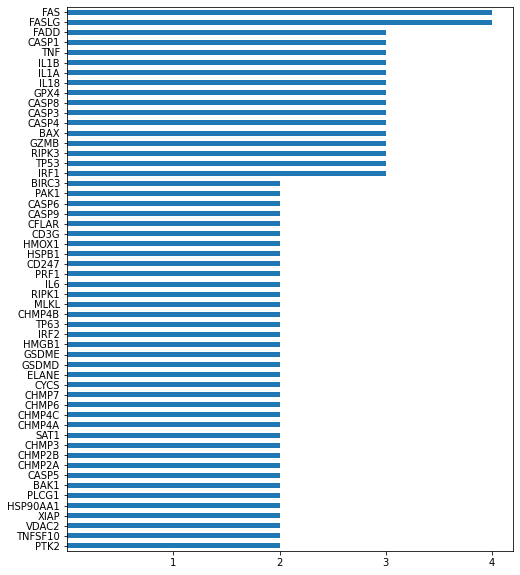

In [20]:
plt.rcParams["figure.figsize"] = (8,10)
countgs={}
for gs in genesetdict.keys():
    for g in genesetdict[gs]:
        if g in countgs:
            countgs[g]+=1
        else:
            countgs[g]=1
countser=pd.Series(countgs)
countser[countser>1].sort_values().plot.barh()
plt.xticks([1,2,3,4])

In [21]:
tcgagenemap.index=tcgagenemap.index.to_series().apply(lambda x: x.split('.')[0]).values.tolist()

In [22]:
tcgagenemap.loc['ENSG00000203805']

gene           PPAPDC1A
chrom             chr10
chromStart    120456954
chromEnd      120589855
strand                +
Name: ENSG00000203805, dtype: object

In [23]:
candf=pd.Series(can_dict_counts)
candf.sort_values(inplace=True)
matrixlist=list(candf.loc[candf>=10].index)

In [24]:
allcorelist = [item for sublist in nodup_ensgeneset.values() for item in sublist]

In [25]:
len(allcorelist)

403

In [26]:
tumour_subtype=pd.read_csv('/Users/jayashankara2/Desktop/Hannenhalli_rotation/subtype_purity/pancan2018_subtypes.tsv',sep='\t',index_col=0)
samlist=tumour_subtype.index.to_series().apply(lambda x: x[:12]).values.tolist()
tumour_subtype.index=samlist
tumour_subtype.head()

,cancer.type,Subtype_mRNA,Subtype_DNAmeth,Subtype_protein,Subtype_miRNA,Subtype_CNA,Subtype_Integrative,Subtype_other,Subtype_Selected
TCGA-OR-A5J1,ACC,steroid-phenotype-high+proliferation,CIMP-high,NaN,miRNA_1,Quiet,COC3,C1A,ACC.CIMP-high
TCGA-OR-A5J2,ACC,steroid-phenotype-high+proliferation,CIMP-low,1.0,miRNA_1,Noisy,COC3,C1A,ACC.CIMP-low
TCGA-OR-A5J3,ACC,steroid-phenotype-high,CIMP-intermediate,3.0,miRNA_6,Chromosomal,COC2,C1A,ACC.CIMP-intermediate
TCGA-OR-A5J4,ACC,NaN,CIMP-high,NaN,miRNA_6,Chromosomal,NaN,NaN,ACC.CIMP-high
TCGA-OR-A5J5,ACC,steroid-phenotype-high,CIMP-intermediate,NaN,miRNA_2,Chromosomal,COC2,C1A,ACC.CIMP-intermediate


In [100]:
tumour_purity=pd.read_csv('/Users/jayashankara2/Desktop/Hannenhalli_rotation/subtype_purity/tumour_purity.tsv',sep='\t',index_col=0)

In [101]:
samlist=tumour_purity.index.to_series().apply(lambda x: x[:15]).values.tolist()
tumour_purity.index=samlist
tumour_purity.index=tumour_purity.index.to_series().apply(lambda x: x.replace("-",".")).values.tolist()
tumour_purity.dropna(inplace=True,subset=['CPE'])

In [102]:
tumour_purity["CPE"]=tumour_purity["CPE"].apply(lambda x: float(x.replace(",",".")))

In [103]:
tumour_purity = tumour_purity[~tumour_purity.index.duplicated(keep='first')]

In [104]:
def coxregsurvival_all(exp,surv,spgenes=[]):
    from sksurv.compare import compare_survival
    from sksurv.nonparametric import kaplan_meier_estimator
    from lifelines import CoxPHFitter
    import lifelines
    import sksurv as sk
    from sksurv.preprocessing import OneHotEncoder
    clindata=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.basic_phenotype.tsv.gz", sep="\t", index_col=0)
    clindata.index=clindata.index.str.strip().str[:-1]
    clindata.index=clindata.index.to_series().apply(lambda x: x.replace("-",".")).values.tolist()
    clindata = clindata[~clindata.index.duplicated(keep='first')]
    surv['OS']=surv['OS']==1
    if len(spgenes)!=0:
        exp=exp[spgenes]
    else:
        spgenes=exp.columns.to_list()
    exp["age"]=clindata["Age at Diagnosis in Years"]
    exp["gender"]=clindata["Gender"]
    exp.dropna(inplace=True,subset=['gender'])
    exp.dropna(inplace=True,subset=['age'])
    exp["OS"]=surv["OS"]
    exp["OS.time"]=surv["OS.time"]
    exp['gender']=exp['gender'].astype("category")
    exp['OS']=exp['OS'].astype("category")
    exp["purity"]=tumour_purity["CPE"]
    exp.dropna(inplace=True)
    coxdict={}
    for g in spgenes:
        try:
            Xt = OneHotEncoder().fit_transform(exp[[g,"age","gender","OS","OS.time","purity"]])
            cph = CoxPHFitter()
            coxdict[g]=cph.fit(Xt, duration_col='OS.time', event_col='OS=True').summary
        except:
            coxdict[g]=pd.DataFrame()
    return coxdict

In [35]:
test=pd.read_csv("ssgsea/Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp _ssgsea_mat.tsv",sep="\t")

In [36]:
test

,TCGA.C8.A1HL.01,TCGA.EW.A2FS.01,TCGA.B6.A402.01,TCGA.A2.A3XX.01,TCGA.Z7.A8R5.01,TCGA.D8.A1JU.01,TCGA.B6.A0RL.01,TCGA.E9.A3HO.01,TCGA.BH.A0B0.01,TCGA.D8.A1XJ.01,...,TCGA.OL.A97C.01,TCGA.A2.A25D.01,TCGA.BH.A18G.01,TCGA.B6.A0IA.01,TCGA.A8.A090.01,TCGA.5T.A9QA.01,TCGA.AN.A0XT.01,TCGA.A2.A0YK.01,TCGA.A8.A09K.01,TCGA.A2.A1FV.01
rev_CTL,0.342375,0.420506,0.277846,0.393638,0.447206,0.484868,0.274851,0.365358,0.535287,0.426274,...,0.433369,0.537278,0.424250,0.360547,0.456475,0.367217,0.265258,0.643756,0.403012,0.188631
HALLMARK_APOPTOSIS,0.561872,0.560534,0.454886,0.516274,0.542023,0.645370,0.405086,0.475616,0.637289,0.546938,...,0.634374,0.615192,0.567457,0.541238,0.625931,0.439485,0.530065,0.678250,0.488790,0.526356
REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,0.145085,0.572420,0.173613,0.627678,0.255868,0.485900,0.105769,0.110089,0.378660,0.292313,...,0.202976,0.494639,0.105899,0.101348,0.344559,0.006590,0.400214,0.745550,0.649497,0.182242
Rev_Pyroptosis,0.407416,0.368613,0.203422,0.394424,0.424434,0.416843,0.343012,0.359188,0.488829,0.347122,...,0.362551,0.415183,0.483187,0.366681,0.418358,0.360217,0.328074,0.467752,0.392631,0.015458
REACTOME_REGULATED_NECROSIS,0.449329,0.460203,0.380809,0.510926,0.509122,0.504859,0.442929,0.431114,0.536306,0.443577,...,0.447970,0.514463,0.549710,0.431159,0.530413,0.454143,0.454755,0.552246,0.435708,0.211159
Rev_Ferroptosis,0.511270,0.419784,0.532373,0.558691,0.593203,0.631637,0.515025,0.373037,0.584267,0.726269,...,0.522693,0.542881,0.588102,0.538842,0.633351,0.506548,0.535052,0.652786,0.470806,0.555355
rand_1,0.282866,0.324511,0.274989,0.267851,0.391484,0.276707,-0.047582,0.383917,0.350699,0.168834,...,0.101647,0.185775,0.294864,0.312169,0.194594,0.224341,0.229185,0.282063,0.082958,0.127682
rand_2,0.232964,0.171353,0.303238,0.309666,0.234638,0.444442,0.034530,0.234705,0.251077,0.234415,...,0.214995,0.225682,0.373379,0.204485,0.097526,0.220709,0.162311,0.368459,0.025607,0.229114
rand_3,0.375460,0.438703,0.419443,0.413393,0.399945,0.551513,0.518982,0.315688,0.463755,0.540582,...,0.557340,0.422878,0.360619,0.384118,0.494614,0.413404,0.526983,0.578230,0.410047,0.489755
rand_4,0.228230,0.179824,0.160206,0.055175,0.119093,0.103735,0.104196,0.116426,0.115978,0.113836,...,0.217899,0.132005,0.018984,0.224932,0.065904,0.119568,-0.032273,-0.005849,0.121038,0.286891


In [105]:
survcan=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/TCGA_TARGET_GTex/TCGA_survival_data.gz",index_col=0,sep="\t")
survcan.dropna(inplace=True,subset=['OS','OS.time'])
survcan['group']="all"
survcan.index = survcan.index.str.replace('-','.')
cox_hr_summary={}
for mtype in matrixlist:
    if "Normal" in mtype:
        continue
    test=pd.read_csv("ssgsea/"+mtype+"_geneexp _ssgsea_mat.tsv",sep="\t")
    test.drop(test.loc[test.index.str.startswith("rand")].index,inplace=True)
    cox_hr_summary[mtype]=coxregsurvival_all(test.transpose(),survcan)

dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical 

dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'OS', because it has only 0 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 1 values
dropped categorical variable 'gender', because it has only 0 values
dropped categorical variable 'gender', because it has only 0 values
dropped categorical variable 'gender', because it has only 0 values
dropped categorical variable 'gender', because it has only 0 values
dropped categorical variable 'gender', because it has only 0 values
dropped categorical variable 'gender', because it has only 0

In [106]:
cox_hr_summary

{'Acute Myeloid Leukemia, Induction Failure Subproject_White blood cell_Post treatment Blood Cancer - Bone Marrow': {'rev_CTL': Empty DataFrame
  Columns: []
  Index: [],
  'HALLMARK_APOPTOSIS': Empty DataFrame
  Columns: []
  Index: [],
  'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS': Empty DataFrame
  Columns: []
  Index: [],
  'Rev_Pyroptosis': Empty DataFrame
  Columns: []
  Index: [],
  'REACTOME_REGULATED_NECROSIS': Empty DataFrame
  Columns: []
  Index: [],
  'Rev_Ferroptosis': Empty DataFrame
  Columns: []
  Index: []},
 'Glioblastoma Multiforme_Brain_Recurrent Tumor': {'rev_CTL':                  coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
  covariate                                                                    
  rev_CTL      3.717944  41.179643  4.031464       -4.183581       11.619469   
  age          0.037528   1.038242  0.052642       -0.065649        0.140706   
  gender=Male  3.409827  30.260012  1.741966       -0.004363        6.824017

In [110]:
rev_coxhr_summary={}
for m in cox_hr_summary:
    rev_coxhr_summary[m]={}
    for k in cox_hr_summary[m]:
        if len(cox_hr_summary[m][k])!=0:
            rev_coxhr_summary[m][k]=cox_hr_summary[m][k][['coef','p']]

In [116]:
pd.concat(rev_coxhr_summary["Breast Invasive Carcinoma_Breast_Primary Tumor"].values()).index

Index(['rev_CTL', 'age', 'gender=Male', 'purity', 'HALLMARK_APOPTOSIS', 'age',
       'gender=Male', 'purity',
       'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS', 'age',
       'gender=Male', 'purity', 'Rev_Pyroptosis', 'age', 'gender=Male',
       'purity', 'REACTOME_REGULATED_NECROSIS', 'age', 'gender=Male', 'purity',
       'Rev_Ferroptosis', 'age', 'gender=Male', 'purity'],
      dtype='object', name='covariate')

In [119]:
plt.rcParams["figure.figsize"] = (10,7)
for m in rev_coxhr_summary:
    try:
        pdf=pd.concat(rev_coxhr_summary[m].values())
        pdf.drop(["age","gender=Male","purity"],inplace=True,axis=0)
    except:
        continue
    splot=pdf['coef'].plot.bar()
    pvals=pdf['p'].values
    i=0
    for p in splot.patches:
        splot[i].set_color('r')
        i+=1
    plt.savefig("plots/"+m+"_barchartcoxhr.png")
    plt.close()

In [113]:
tcga_brca_pt_aucell=pd.read_csv("Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp _Aucell.tsv",sep='\t')
tcga_brca_sn_aucell=pd.read_csv("Breast Invasive Carcinoma_Breast_Solid Tissue Normal_geneexp _Aucell.tsv",sep='\t')
gtex_breast_aucell=pd.read_csv("Breast - Mammary Tissue_Breast_Normal Tissue_geneexp _Aucell.tsv",sep='\t')

In [114]:
tcga_brca_pt_aucell

,TCGA.AO.A03M.01,TCGA.AO.A0JD.01,TCGA.A2.A0CT.01,TCGA.B6.A40B.01,TCGA.LQ.A4E4.01,TCGA.AO.A0JJ.01,TCGA.AC.A3QQ.01,TCGA.E9.A3QA.01,TCGA.GM.A2DD.01,TCGA.BH.A0BO.01,...,TCGA.XX.A89A.01,TCGA.BH.A0HF.01,TCGA.C8.A274.01,TCGA.D8.A27N.01,TCGA.GM.A2DK.01,TCGA.A2.A1FZ.01,TCGA.BH.A0HU.01,TCGA.BH.A18V.01,TCGA.BH.A18J.01,TCGA.BH.A18T.01
BIOCARTA_CTL_PATHWAY,0.150510,0.136175,0.129070,0.125919,0.106148,0.148780,0.071671,0.262095,0.169540,0.211863,...,0.167871,0.157059,0.104912,0.153908,0.148347,0.137597,0.143713,0.217362,0.140377,0.147915
GOBP_T_CELL_MEDIATED_CYTOTOXICITY,0.139951,0.144182,0.118036,0.160817,0.121508,0.160980,0.074387,0.160130,0.188591,0.156442,...,0.157834,0.161559,0.132773,0.154453,0.178139,0.155049,0.166079,0.188157,0.138685,0.115631
GOBP_NECROPTOTIC_SIGNALING_PATHWAY,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HALLMARK_APOPTOSIS,0.157802,0.120141,0.158306,0.209340,0.142449,0.199321,0.162889,0.159358,0.181134,0.219085,...,0.201258,0.195457,0.128990,0.185556,0.191336,0.201011,0.152902,0.149092,0.158435,0.098681
REACTOME_AUTOPHAGY,0.146928,0.128484,0.124973,0.118025,0.108526,0.111142,0.058354,0.118164,0.127248,0.115935,...,0.104368,0.127935,0.117506,0.122790,0.139716,0.116813,0.130141,0.106401,0.119983,0.123257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T cells gamma delta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.080622,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Dendritic cells resting,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.039484,0.027359,0.000000,...,0.010399,0.001190,0.000000,0.000000,0.000000,0.004605,0.000000,0.029546,0.000000,0.000000
Dendritic cells activated,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008417,0.000000,0.041079,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.060008,0.000000,0.019855
Eosinophils,0.000000,0.000000,0.000000,0.015320,0.000000,0.000000,0.028839,0.000000,0.013180,0.027978,...,0.022471,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [122]:
tcga_brca_pt_aucell.fillna(0,inplace=True,axis=1)
tcga_brca_sn_aucell.fillna(0,inplace=True,axis=1)
gtex_breast_aucell.fillna(0,inplace=True,axis=1)
tcga_brca_pt_aucell=tcga_brca_pt_aucell.transpose()
tcga_brca_sn_aucell=tcga_brca_sn_aucell.transpose()
gtex_breast_aucell=gtex_breast_aucell.transpose()
tcga_brca_pt_aucell['type']="Primary Tumour"
tcga_brca_sn_aucell['type']="Adjacent Solid Normal"
gtex_breast_aucell['type']="gtex healthy"
allaucell = pd.concat([tcga_brca_pt_aucell,tcga_brca_sn_aucell,gtex_breast_aucell],ignore_index=True)

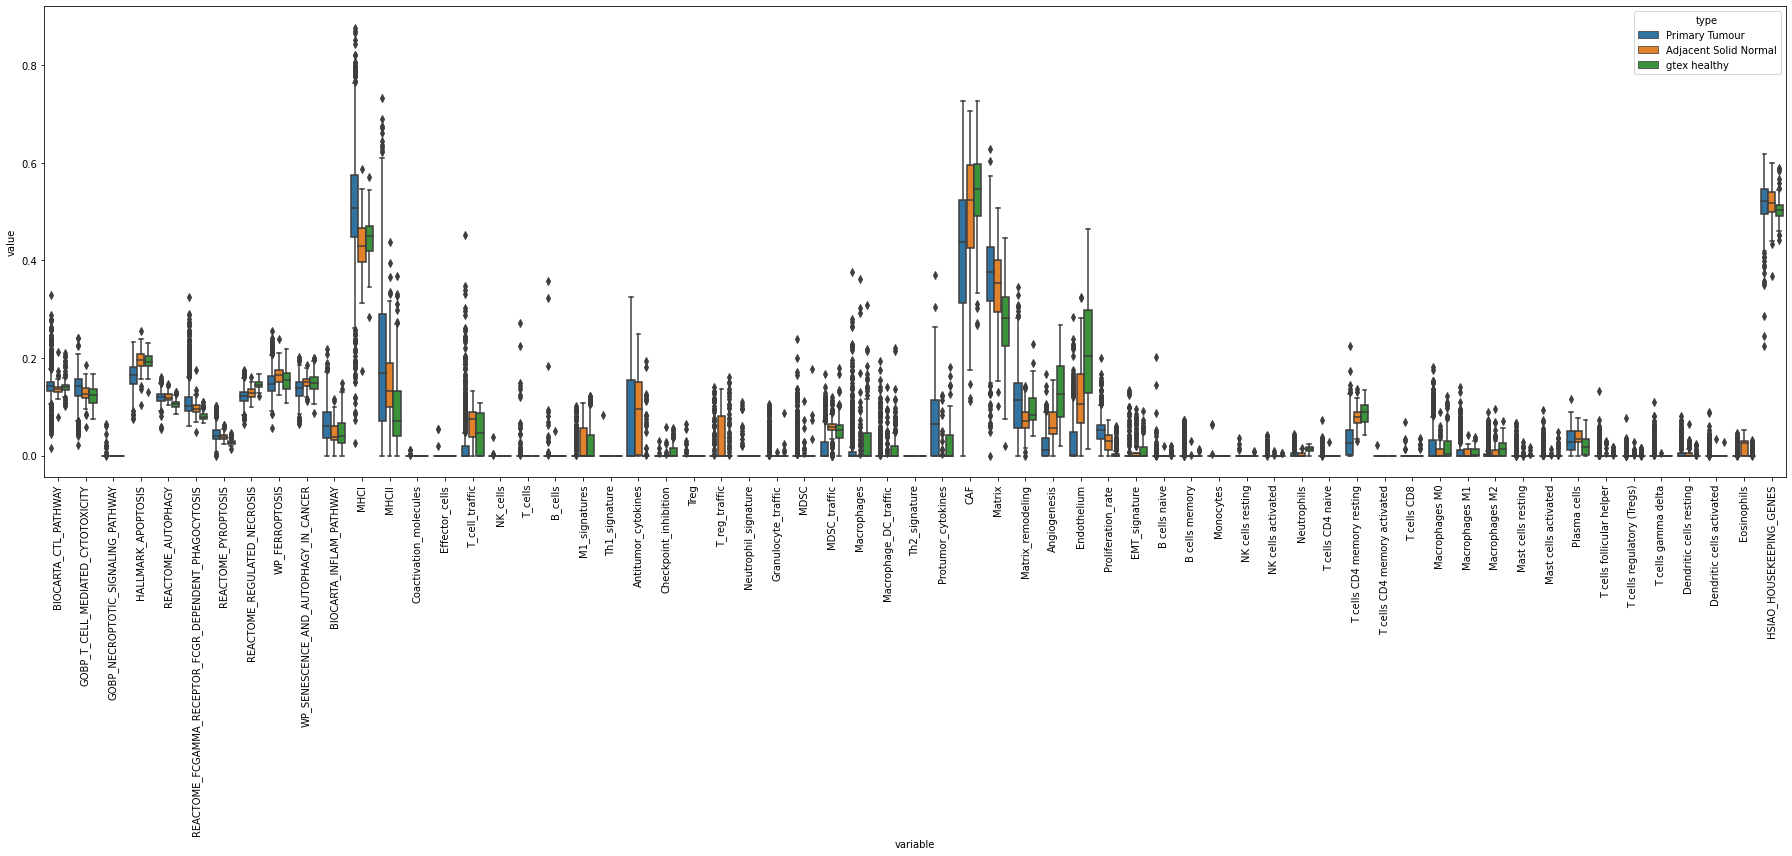

In [125]:
dd=pd.melt(allaucell,id_vars=['type'],value_vars=list(allgex.columns))
plt.figure(figsize=(25,12))
res=sns.boxplot(x='variable',y='value',data=dd, hue='type')
plt.xticks(rotation=90)
plt.tight_layout()
res.figure.savefig("aucell_geneset.png")

[Text(1, 0, 'BIOCARTA_CTL_PATHWAY'),
 Text(2, 0, 'GOBP_T_CELL_MEDIATED_CYTOTOXICITY'),
 Text(3, 0, 'GOBP_NECROPTOTIC_SIGNALING_PATHWAY'),
 Text(4, 0, 'HALLMARK_APOPTOSIS'),
 Text(5, 0, 'REACTOME_AUTOPHAGY'),
 Text(6, 0, 'REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS'),
 Text(7, 0, 'REACTOME_PYROPTOSIS'),
 Text(8, 0, 'REACTOME_REGULATED_NECROSIS'),
 Text(9, 0, 'WP_FERROPTOSIS'),
 Text(10, 0, 'WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER'),
 Text(11, 0, 'BIOCARTA_INFLAM_PATHWAY')]

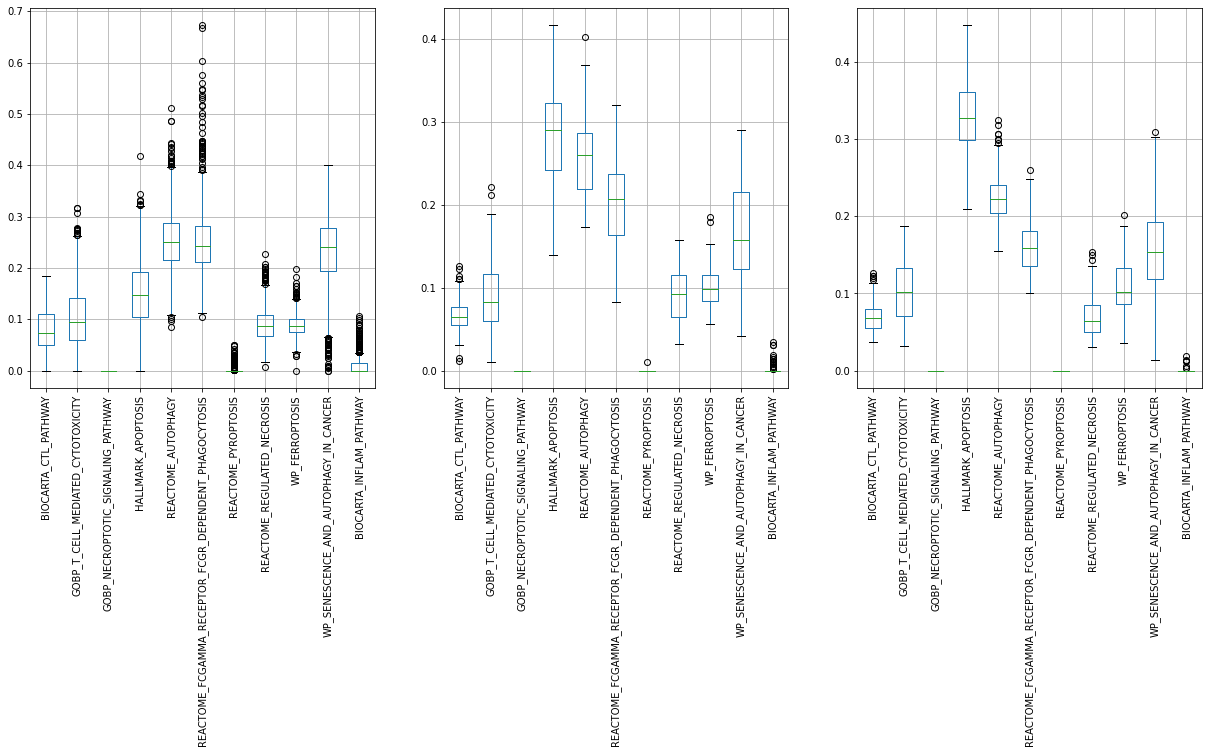

In [221]:
#aucell
plt.rcParams["figure.figsize"] = (21,7)
fig, ax = plt.subplots(nrows=1, ncols=3)
tcga_brca_pt_aucell.transpose().boxplot(ax=ax[0])
ax[0].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)
tcga_brca_sn_aucell.transpose().boxplot(ax=ax[1])
ax[1].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)
gtex_breast_aucell.transpose().boxplot(ax=ax[2])
ax[2].set_xticklabels(labels=tcga_brca_pt_aucell.index,rotation=90)

In [53]:
def meangensetexp(df,geneset):
    newdf=pd.DataFrame(index=geneset.keys(),columns=df.columns)
    for g in geneset:
        newdf.loc[g]=df.loc[df.index.intersection(geneset[g]),:].mean()
    return(newdf)

In [93]:
brcapt=pd.read_csv("geneexp/Breast Invasive Carcinoma_Breast_Primary Tumor_geneexp.tsv",sep="\t",index_col=0)
brcasn=pd.read_csv("geneexp/Breast Invasive Carcinoma_Breast_Solid Tissue Normal_geneexp.tsv",sep="\t",index_col=0)
gtexbreast=pd.read_csv("geneexp/Breast - Mammary Tissue_Breast_Normal Tissue_geneexp.tsv",sep="\t",index_col=0)

In [94]:
brcapt_cds_mge=meangensetexp(brcapt,ensgeneset)
brcasn_cds_mge=meangensetexp(brcasn,ensgeneset)
gtexbr_cds_mge=meangensetexp(gtexbreast,ensgeneset)

In [95]:
brcapt_cds_mge.fillna(0,inplace=True,axis=1)
brcasn_cds_mge.fillna(0,inplace=True,axis=1)
gtexbr_cds_mge.fillna(0,inplace=True,axis=1)
brcapt_cds_mge=brcapt_cds_mge.transpose()
brcasn_cds_mge=brcasn_cds_mge.transpose()
gtexbr_cds_mge=gtexbr_cds_mge.transpose()
brcapt_cds_mge['type']="Primary Tumour"
brcasn_cds_mge['type']="Adjacent Solid Normal"
gtexbr_cds_mge['type']="gtex healthy"
allgex = pd.concat([brcapt_cds_mge,brcasn_cds_mge,gtexbr_cds_mge],ignore_index=True)

In [96]:
allgex

,BIOCARTA_CTL_PATHWAY,GOBP_T_CELL_MEDIATED_CYTOTOXICITY,GOBP_NECROPTOTIC_SIGNALING_PATHWAY,HALLMARK_APOPTOSIS,REACTOME_AUTOPHAGY,REACTOME_FCGAMMA_RECEPTOR_FCGR_DEPENDENT_PHAGOCYTOSIS,REACTOME_PYROPTOSIS,REACTOME_REGULATED_NECROSIS,WP_FERROPTOSIS,WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER,...,Mast cells activated,Plasma cells,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,Dendritic cells resting,Dendritic cells activated,Eosinophils,HSIAO_HOUSEKEEPING_GENES,type
0,10.782285,9.495411,8.536250,11.116919,10.960353,10.783987,9.930215,10.832700,11.113268,10.602233,...,4.409509,7.229595,8.756558,6.517978,6.113553,8.299257,8.200425,7.082132,13.465510,Primary Tumour
1,8.819146,8.740435,7.850950,10.165425,10.150955,8.679204,9.319089,10.179164,10.666118,9.710215,...,3.984009,5.425445,7.106558,5.525254,5.059324,7.722138,6.850755,6.158315,12.931416,Primary Tumour
2,7.010200,7.584483,7.013338,10.164040,10.008479,8.132310,8.970233,9.731088,10.164450,9.823799,...,4.034777,4.987150,6.067392,4.630798,4.424776,6.748167,6.186540,6.209226,12.552148,Primary Tumour
3,8.439177,9.064787,8.758275,11.315460,10.949683,9.317338,10.065226,10.948850,10.761003,10.867666,...,6.310036,6.349761,7.267365,5.862322,5.150618,8.213157,7.410250,7.378541,13.703011,Primary Tumour
4,7.193115,7.750952,7.633750,10.106456,10.328445,7.224470,8.557044,9.868514,10.191355,9.730520,...,4.329241,5.188200,6.152869,5.031951,4.191465,6.414190,5.924220,5.981847,12.780686,Primary Tumour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378,8.192808,7.579139,7.520550,9.666174,9.615595,6.455459,8.241248,9.516393,9.702452,9.179932,...,3.539618,4.554082,6.071227,4.266717,4.453771,5.661181,5.856045,5.819615,12.119545,gtex healthy
1379,7.803615,7.872480,7.299650,9.982830,9.796177,6.401635,8.563719,9.723107,10.127978,9.532395,...,3.964614,4.621982,6.062804,4.945785,4.736159,5.792762,6.196750,5.887621,12.229458,gtex healthy
1380,7.335862,7.761330,6.934312,10.116748,9.720959,6.938534,8.305752,9.633096,9.981103,9.633669,...,4.114141,5.199974,6.181504,4.376407,4.428124,5.637481,5.917105,6.237835,12.420099,gtex healthy
1381,7.660538,7.551552,7.340788,9.943606,9.714446,6.304734,8.396319,9.603080,9.872230,9.279041,...,3.112273,5.010366,6.017831,4.392554,4.186647,5.743348,6.000490,5.789482,12.154080,gtex healthy


In [126]:
dd=pd.melt(allgex,id_vars=['type'],value_vars=list(allgex.columns))

In [105]:
dd

,type,variable,value
0,Primary Tumour,BIOCARTA_CTL_PATHWAY,10.782285
1,Primary Tumour,BIOCARTA_CTL_PATHWAY,8.819146
2,Primary Tumour,BIOCARTA_CTL_PATHWAY,7.010200
3,Primary Tumour,BIOCARTA_CTL_PATHWAY,8.439177
4,Primary Tumour,BIOCARTA_CTL_PATHWAY,7.193115
...,...,...,...
87124,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.119545
87125,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.229458
87126,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.420099
87127,gtex healthy,HSIAO_HOUSEKEEPING_GENES,12.154080


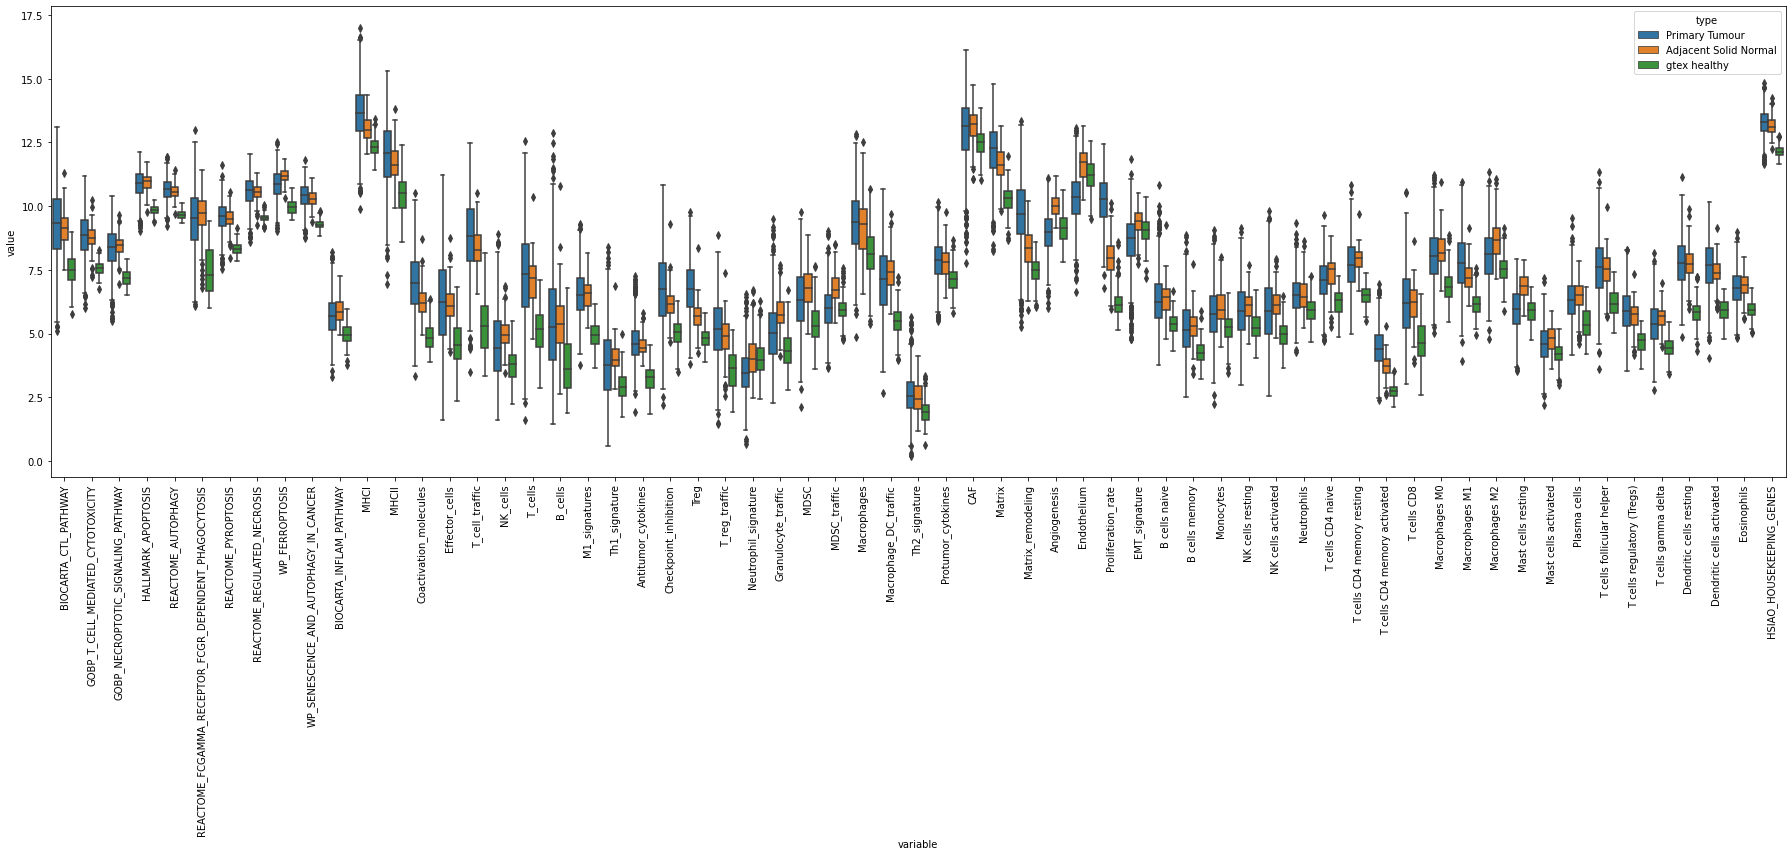

In [127]:
plt.figure(figsize=(25,12))
res=sns.boxplot(x='variable',y='value',data=dd, hue='type')
plt.xticks(rotation=90)
plt.tight_layout()
res.figure.savefig("mean_geneset_expression.png")

[Text(1, 0, 'REACTOME_AUTOPHAGY_geneset'),
 Text(2, 0, 'HALLMARK_APOPTOSIS_geneset'),
 Text(3, 0, 'GOBP_NECROPTOTIC_sig_geneset'),
 Text(4, 0, 'REACTOME_FCGR_DEPENDENT_PHAGOCYTOSIS_geneset'),
 Text(5, 0, 'GOBP_CTL_geneset'),
 Text(6, 0, 'inflammatory_geneset'),
 Text(7, 0, 'BIOCARTA_CTL_PATHWAY_geneset'),
 Text(8, 0, 'REACTOME_REGULATED_NECROSIS_geneset'),
 Text(9, 0, 'REACTOME_PYROPTOSIS_geneset'),
 Text(10, 0, 'WP_FERROPTOSIS_geneset'),
 Text(11, 0, 'WP_SENESCENCE_AND_AUTOPHAGY_IN_CANCER_geneset')]

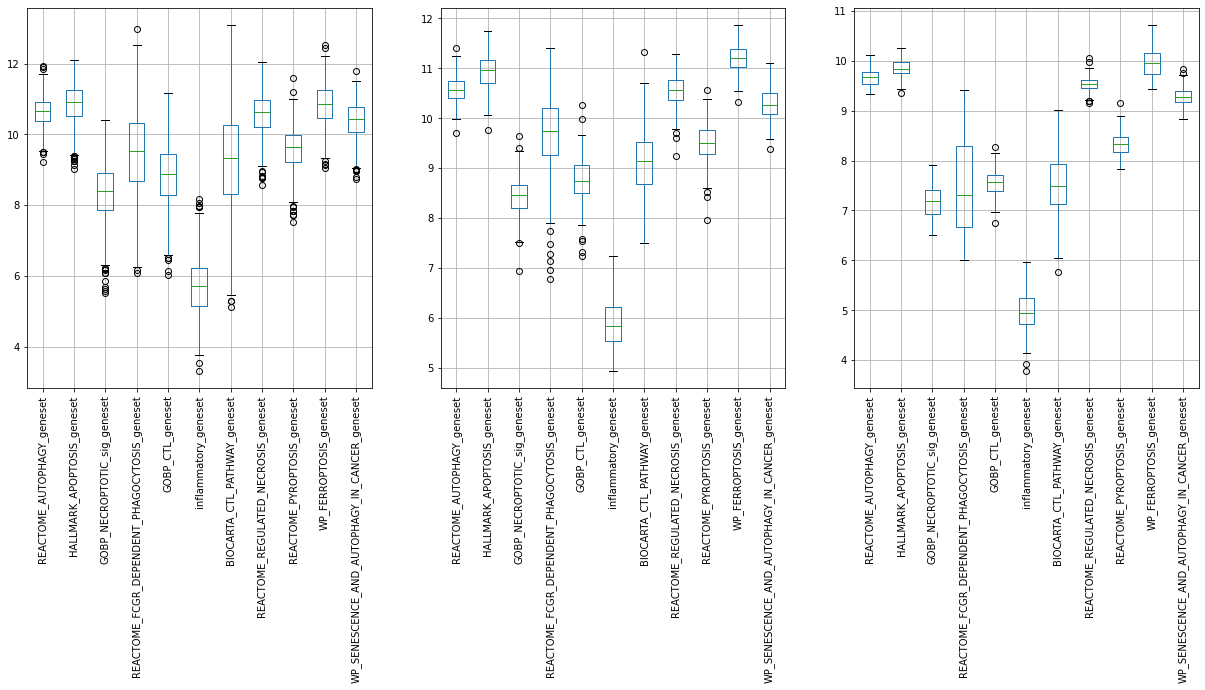

In [188]:
#mean expression
fig, ax = plt.subplots(nrows=1, ncols=3)
brcapt_cds_mge.transpose().boxplot(ax=ax[0])
ax[0].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)
brcasn_cds_mge.transpose().boxplot(ax=ax[1])
ax[1].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)
gtexbr_cds_mge.transpose().boxplot(ax=ax[2])
ax[2].set_xticklabels(labels=brcapt_cds_mge.index,rotation=90)

In [189]:
del genexpmatrix

In [191]:
mutationmatrix=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.mutect2_snv.tsv.gz",sep="\t",index_col=0)
nonsyn_mutmatrix=mutationmatrix.loc[~mutationmatrix["effect"].str.contains("synonymous_variant")].copy()

In [192]:
test=pd.crosstab(columns=nonsyn_mutmatrix.index, index=nonsyn_mutmatrix.gene)
test.head()

col_0,TCGA-02-0003-01A,TCGA-02-0033-01A,TCGA-02-0047-01A,TCGA-02-0055-01A,TCGA-02-2466-01A,TCGA-02-2470-01A,TCGA-02-2483-01A,TCGA-02-2485-01A,TCGA-02-2486-01A,TCGA-04-1331-01A,...,TCGA-ZP-A9D4-01A,TCGA-ZQ-A9CR-01A,TCGA-ZR-A9CJ-01B,TCGA-ZS-A9CD-01A,TCGA-ZS-A9CE-01A,TCGA-ZS-A9CF-01A,TCGA-ZS-A9CG-01A,TCGA-ZT-A8OM-01A,TCGA-ZU-A8S4-01A,TCGA-ZX-AA5X-01A
gene,,,,,,,,,,,,,,,,,,,,,
A1BG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2ML1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2MP1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [193]:
mm_hgnclist=test.index.to_list()
mm_hgnclist
mm_enslist=[]
for g in mm_hgnclist:
    try:
        mm_enslist.append(tcgaensdict[g])
    except KeyError:
        print(g)
        mm_enslist.append(g)

AC104809.3
AC114494.1
AC138969.4
AL022328.1
B3GALTL
C12orf5
C14orf183
C17orf70
C19orf40
C19orf83
C1orf86
C2orf43
C6orf195
CCL4L1
CSNK2B-LY6G5B--991
DAK
FAIM3
IGJ
KAL1
KIAA1045
KIAA1279
KIAA1598
MIR4435-1HG
NBPF8P
PROSP
RP11-1220K2.2
RP11-162O12.2
RP11-350A1.1
RP11-38M15.11
RP11-396K3.1
RP11-402J6.2
RP11-536C10.25
RP11-551L14.1
RP11-642P15.1
RP11-683L23.1
RP11-944L7.5
RP13-7D7.1
RP5-907C10.4
RPSAP56
T1560
TMEM194A
TMEM194B
Unknown
ZSCAN5C
hsa-mir-6511b-1


In [194]:
test.index=mm_enslist
test.head()

col_0,TCGA-02-0003-01A,TCGA-02-0033-01A,TCGA-02-0047-01A,TCGA-02-0055-01A,TCGA-02-2466-01A,TCGA-02-2470-01A,TCGA-02-2483-01A,TCGA-02-2485-01A,TCGA-02-2486-01A,TCGA-04-1331-01A,...,TCGA-ZP-A9D4-01A,TCGA-ZQ-A9CR-01A,TCGA-ZR-A9CJ-01B,TCGA-ZS-A9CD-01A,TCGA-ZS-A9CE-01A,TCGA-ZS-A9CF-01A,TCGA-ZS-A9CG-01A,TCGA-ZT-A8OM-01A,TCGA-ZU-A8S4-01A,TCGA-ZX-AA5X-01A
ENSG00000121410,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000148584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000175899,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000166535,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000256069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [195]:
def agg_mutations(df,geneset):
    newdf=pd.DataFrame(index=geneset.keys(),columns=df.columns)
    for g in geneset:
        newdf.loc[g]=df.loc[df.index.intersection(geneset[g]),:].sum()
    return(newdf)

In [205]:
brcapt_snv=test.loc[test.index.intersection(list(gsgenemap.values())),test.columns.intersection(can_dict['TCGA-BRCA'])].copy()

In [206]:
brcapt_snv

col_0,TCGA-3C-AAAU-01A,TCGA-3C-AALI-01A,TCGA-3C-AALJ-01A,TCGA-3C-AALK-01A,TCGA-4H-AAAK-01A,TCGA-5L-AAT0-01A,TCGA-5L-AAT1-01A,TCGA-5T-A9QA-01A,TCGA-A1-A0SD-01A,TCGA-A1-A0SE-01A,...,TCGA-UL-AAZ6-01A,TCGA-UU-A93S-01A,TCGA-V7-A7HQ-01A,TCGA-W8-A86G-01A,TCGA-WT-AB41-01A,TCGA-WT-AB44-01A,TCGA-XX-A899-01A,TCGA-XX-A89A-01A,TCGA-Z7-A8R5-01A,TCGA-Z7-A8R6-01A
ENSG00000136754,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000138443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000097007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000151726,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000123983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000070540,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000157954,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000143184,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000101966,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [211]:
brcapt_aggcds=agg_mutations(brcapt_snv,ensgeneset)
brcapt_aggcds.fillna(0,inplace=True)

(-1.0, 5.0)

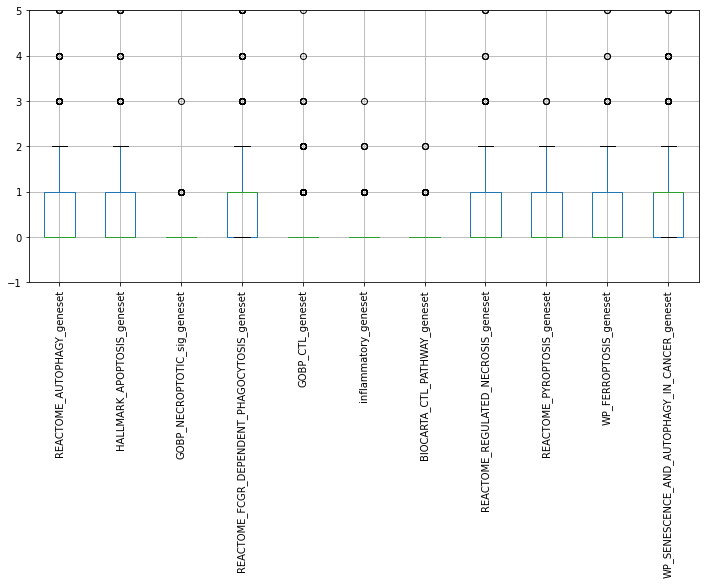

In [217]:
#aggmutations
plt.rcParams["figure.figsize"] = (12,5)
brcapt_aggcds.transpose().boxplot()
plt.xticks(rotation=90)
plt.ylim(-1,5)

In [202]:
cat_sample=pd.read_csv("/Users/jayashankara2/Desktop/Hannenhalli_rotation/genelist/gdc_PANCAN/GDC-PANCAN.basic_phenotype.tsv", sep="\t",index_col=0)
cat_sample.dropna(inplace=True)
cat_sample.drop(cat_sample.loc[cat_sample['sample_type'].str.contains("Normal")].index,inplace=True)
cat_sdit=dict(cat_sample['project_id'])

In [203]:
can_dict={}
for s in cat_sdit:
    if cat_sdit[s] not in can_dict.keys():
        can_dict[cat_sdit[s]]=[]
        can_dict[cat_sdit[s]].append(s)
    else:
        can_dict[cat_sdit[s]].append(s)